# 비지도학습 — 클러스터링(Clustering) 학습 노트

**학습 목표**
- K-Means 알고리즘의 원리와 사용법을 익힌다.
- 클러스터링 결과를 PCA로 시각화하는 방법을 이해한다.
- 실루엣 계수(Silhouette Score)로 클러스터 품질을 정량 평가한다.
- 최적 클러스터 개수(K)를 선택하는 방법을 익힌다.

---

## 1. K-Means 클러스터링

### 원리
1. K개의 초기 중심(centroid) 설정
2. 각 데이터를 가장 가까운 중심에 할당
3. 할당된 데이터들의 평균으로 중심 업데이트
4. 중심이 변하지 않을 때까지 2~3 반복

**`init='k-means++'`**: 초기 중심을 무작위가 아니라 서로 멀리 떨어지도록 설정 → 더 빠른 수렴, 더 안정적인 결과

In [27]:
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

### 1-1. 붓꽃 데이터 K-Means 클러스터링

In [ ]:
#dataframe으로
iris = load_iris()
irisDF = pd.DataFrame(data=iris.data,
                      columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
irisDF.head(3)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [3]:
# K-Means 학습
# n_clusters=3 : 붓꽃 3종 → K=3
# max_iter=300 : 중심 업데이트 최대 횟수
# random_state : 재현성 확보
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=0)
kmeans.fit(irisDF)

# labels_ : 각 샘플에 할당된 클러스터 번호 (0, 1, 2 중 하나)
print(kmeans.labels_)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


In [4]:
# 실제 정답(target)과 클러스터 할당 결과 비교
# K-Means는 정답 레이블 없이 학습 → 클러스터 번호는 임의 부여됨
irisDF['target']  = iris.target
irisDF['cluster'] = kmeans.labels_

iris_result = irisDF.groupby(['target', 'cluster'])['sepal_length'].count()
print(iris_result)
# target=0(setosa)은 cluster 1에 50개 → 완벽히 분리
# target=1, 2는 일부 혼재 → K-Means가 선형 경계에 약하기 때문

target  cluster
0       1          50
1       0          47
        2           3
2       0          14
        2          36
Name: sepal_length, dtype: int64


### 1-2. PCA로 고차원 데이터 2D 시각화

붓꽃 데이터는 4차원(feature 4개) → 눈으로 직접 볼 수 없음  
**PCA(Principal Component Analysis)**: 분산을 최대한 보존하면서 차원 축소 → 2D 산점도로 클러스터 분포 확인

In [5]:
# PCA로 4D → 2D 축소
pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(iris.data)

irisDF['pca_x'] = pca_transformed[:, 0]  # PC1 (가장 분산이 큰 축)
irisDF['pca_y'] = pca_transformed[:, 1]  # PC2
irisDF.head(3)

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,pca_x,pca_y
0,5.1,3.5,1.4,0.2,0,1,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,0,1,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,0,1,-2.888991,-0.144949


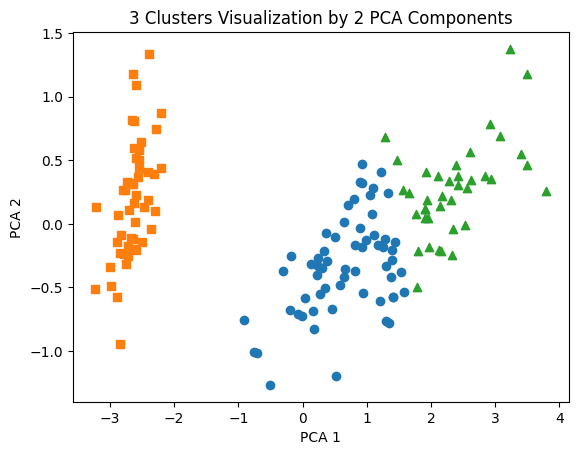

In [ ]:
# 클러스터별로 다른 마커(o, s, ^)로 산점도 출력
# 0,1,2 경우 마다 별도로
marker0_ind = irisDF[irisDF['cluster'] == 0].index
marker1_ind = irisDF[irisDF['cluster'] == 1].index
marker2_ind = irisDF[irisDF['cluster'] == 2].index
# 군집 값 0, 1, 2에 해당하는 인덱스로 각 군집 레벨의 pca_x, pca_y 값 추출. o, s, ^ 로 마커 표시
plt.scatter(x=irisDF.loc[marker0_ind, 'pca_x'], y=irisDF.loc[marker0_ind, 'pca_y'], marker='o')
plt.scatter(x=irisDF.loc[marker1_ind, 'pca_x'], y=irisDF.loc[marker1_ind, 'pca_y'], marker='s')
plt.scatter(x=irisDF.loc[marker2_ind, 'pca_x'], y=irisDF.loc[marker2_ind, 'pca_y'], marker='^')

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('3 Clusters Visualization by 2 PCA Components')
plt.show()

### 1-3. make_blobs — 테스트용 인공 데이터 생성

실제 데이터 없이 클러스터링 실험을 위한 인공 데이터 생성  
`centers`: 클러스터 중심 개수, `cluster_std`: 클러스터 내 퍼짐 정도

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
%matplotlib inline

# 3개 중심, 200개 샘플, 2개 feature(2D 좌표)
X, y = make_blobs(n_samples=200, n_features=2, centers=3, cluster_std=0.8, random_state=0)
print(X.shape, y.shape)  # (200, 2), (200,)

# 클래스별 샘플 수 확인
unique, counts = np.unique(y, return_counts=True)
print(unique, counts)

(200, 2) (200,)
[0 1 2] [67 67 66]


In [4]:
import pandas as pd
clusterDF = pd.DataFrame(data=X, columns=['ftr1', 'ftr2'])
clusterDF['target'] = y
clusterDF.head(3)

,ftr1,ftr2,target
0,-1.692427,3.622025,2
1,0.697940,4.428867,0
2,1.100228,4.606317,0


C:\Users\hyoli\anaconda3\envs\tf\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hyoli\anaconda3\envs\tf\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hyoli\anaconda3\envs\tf\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hyoli\anaconda3\envs\tf\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hyoli\anaconda3\envs\tf\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) De

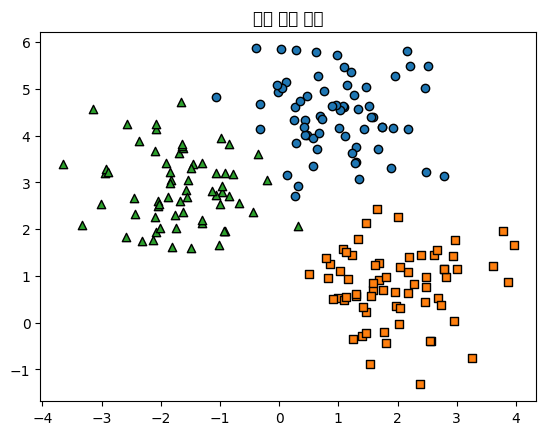

In [5]:
# 원래 정답(target) 기준 산점도
target_list = np.unique(y)
markers = ['o', 's', '^', 'P', 'D', 'H', 'x']
# 3개의 군집 영역으로 구분한 데이터 세트를 생성했으므로 target_list는 [0, 1, 2]
# target==0, target==1, target==2 로 scatter plot을 marker별로 생성.
for target in target_list:
    target_cluster = clusterDF[clusterDF['target'] == target]
    plt.scatter(x=target_cluster['ftr1'], y=target_cluster['ftr2'],
                edgecolor='k', marker=markers[target])

plt.title('원래 정답 분포')
plt.show()

In [26]:
print("X의 행 개수:", len(X))
print("clusterDF의 행 개수:", len(clusterDF))
print("예측된 라벨 개수:", len(cluster_labels))

X의 행 개수: 500
clusterDF의 행 개수: 200
예측된 라벨 개수: 500


In [ ]:
#  학습에 사용한 X의 데이터와 컬럼명을 가지고 새 데이터프레임 생성
# (컬럼명이 ftr1, ftr2가 맞는지 확인하세요)
clusterDF = pd.DataFrame(data=X, columns=['ftr1', 'ftr2'])

#  개수가 정확히 일치 에러 없이 . 자꾸 에러떠서.
clusterDF['kmeans_label'] = cluster_labels

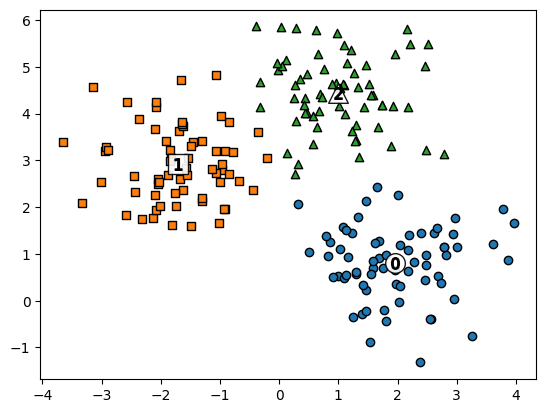

In [6]:
# KMeans 객체를 이용하여 X 데이터를 K-Means 클러스터링 수행 
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=200, random_state=0)
cluster_labels = kmeans.fit_predict(X)
clusterDF['kmeans_label']  = cluster_labels

#cluster_centers_ 는 개별 클러스터의 중심 위치 좌표 시각화를 위해 추출
centers = kmeans.cluster_centers_
unique_labels = np.unique(cluster_labels)
markers=['o', 's', '^', 'P','D','H','x']

# 군집된 label 유형별로 iteration 하면서 marker 별로 scatter plot 수행. 
for label in unique_labels:
    label_cluster = clusterDF[clusterDF['kmeans_label']==label]
    center_x_y = centers[label]
    plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k', 
                marker=markers[label] )
    
    # 군집별 중심 위치 좌표 시각화 
    plt.scatter(x=center_x_y[0], y=center_x_y[1], s=200, color='white',
                alpha=0.9, edgecolor='k', marker=markers[label])
    plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k', edgecolor='k', 
                marker='$%d$' % label)

plt.show()

In [11]:
# 정답 vs K-Means 결과 비교
print(clusterDF.groupby('target')['kmeans_label'].value_counts())
# target 0 → 거의 모두 같은 클러스터 → 잘 분리됨
# 일부 혼재가 있으면 경계가 모호한 데이터

target  kmeans_label
0       2               66
        1                1
1       0               67
2       1               65
        0                1
Name: count, dtype: int64


---
## 2. 클러스터링 평가 — 실루엣 분석 (Silhouette Analysis)

비지도학습은 정답 레이블이 없어서 분류 정확도로 평가할 수 없음  
→ **실루엣 계수**로 클러스터 내부 응집도 & 클러스터 간 분리도를 정량화

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

- $a(i)$: 같은 클러스터 내 다른 점들과의 평균 거리 (낮을수록 좋음)
- $b(i)$: 가장 가까운 다른 클러스터 점들과의 평균 거리 (높을수록 좋음)
- 범위: $-1 \leq s(i) \leq 1$, **1에 가까울수록 좋은 클러스터링**

In [12]:
from sklearn.preprocessing import scale
from sklearn.metrics import silhouette_samples, silhouette_score

iris  = load_iris()
irisDF = pd.DataFrame(data=iris.data,
                      columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])

kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=0).fit(irisDF)
irisDF['cluster'] = kmeans.labels_

# silhouette_samples: 각 샘플의 실루엣 계수 (1D array)
score_samples = silhouette_samples(iris.data, irisDF['cluster'])
print('shape:', score_samples.shape)  # (150,)

irisDF['silhouette_coeff'] = score_samples

# silhouette_score: 전체 평균 실루엣 계수
average_score = silhouette_score(iris.data, irisDF['cluster'])
print('평균 실루엣 계수: {:.3f}'.format(average_score))

irisDF.head(3)

shape: (150,)
평균 실루엣 계수: 0.551


,sepal_length,sepal_width,petal_length,petal_width,cluster,silhouette_coeff
0,5.1,3.5,1.4,0.2,1,0.852582
1,4.9,3.0,1.4,0.2,1,0.814916
2,4.7,3.2,1.3,0.2,1,0.828797


In [13]:
# 클러스터별 평균 실루엣 계수
# 클러스터 간 값 차이가 클수록 불균형한 클러스터링
irisDF.groupby('cluster')['silhouette_coeff'].mean()

cluster
0    0.422323
1    0.797604
2    0.436842
Name: silhouette_coeff, dtype: float64

### 2-1. 실루엣 시각화로 최적 K 선택

**좋은 클러스터링의 조건**
1. 평균 실루엣 계수가 높다
2. 클러스터별 실루엣 계수가 평균에 가깝다 (균형 잡힌 분리)

In [7]:
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
# 실루엣 분석 metric 값을 구하기 위한 API 추가
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.cm as cm
# 여러개의 클러스터링 갯수를 List로 입력 받아 각각의 실루엣 계수를 면적으로 시각화한 함수 작성
def visualize_silhouette(cluster_lists, X_features):
    """여러 K값에 대한 실루엣 계수를 면적 그래프로 시각화"""
    n_cols = len(cluster_lists)
    # plt.subplots()으로 리스트에 기재된 클러스터링 수만큼 sub figure갖는 axs생성
    fig, axs = plt.subplots(figsize=(4 * n_cols, 4), nrows=1, ncols=n_cols)

    for ind, n_cluster in enumerate(cluster_lists):
        #실루엣 스코어와 개별 데이터의 실루엣 값 계산. 
        clusterer    = KMeans(n_clusters=n_cluster, max_iter=500, random_state=0)
        cluster_labels = clusterer.fit_predict(X_features)

        sil_avg    = silhouette_score(X_features, cluster_labels)
        sil_values = silhouette_samples(X_features, cluster_labels)

        y_lower = 10
        axs[ind].set_title('K = {}\nSilhouette = {}'.format(n_cluster, round(sil_avg, 3)))
        axs[ind].set_xlabel('실루엣 계수')
        axs[ind].set_ylabel('Cluster label')
        axs[ind].set_xlim([-0.1, 1])
        axs[ind].set_ylim([0, len(X_features) + (n_cluster + 1) * 10])
        axs[ind].set_yticks([])
        axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
#클러스터링 객수별로 막대 그래프 
        for i in range(n_cluster):
            ith_cluster_sil_values = sil_values[cluster_labels == i]
            ith_cluster_sil_values.sort()

            size_cluster_i = ith_cluster_sil_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_cluster)
            axs[ind].fill_betweenx(np.arange(y_lower, y_upper), 0,
                                   ith_cluster_sil_values,
                                   facecolor=color, edgecolor=color, alpha=0.7)
            axs[ind].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10

        # 빨간 점선 = 전체 평균 실루엣 계수
        axs[ind].axvline(x=sil_avg, color='red', linestyle='--')

    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
#자꾸 아래  warning이 떠서. 
# 한글 폰트 설정 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

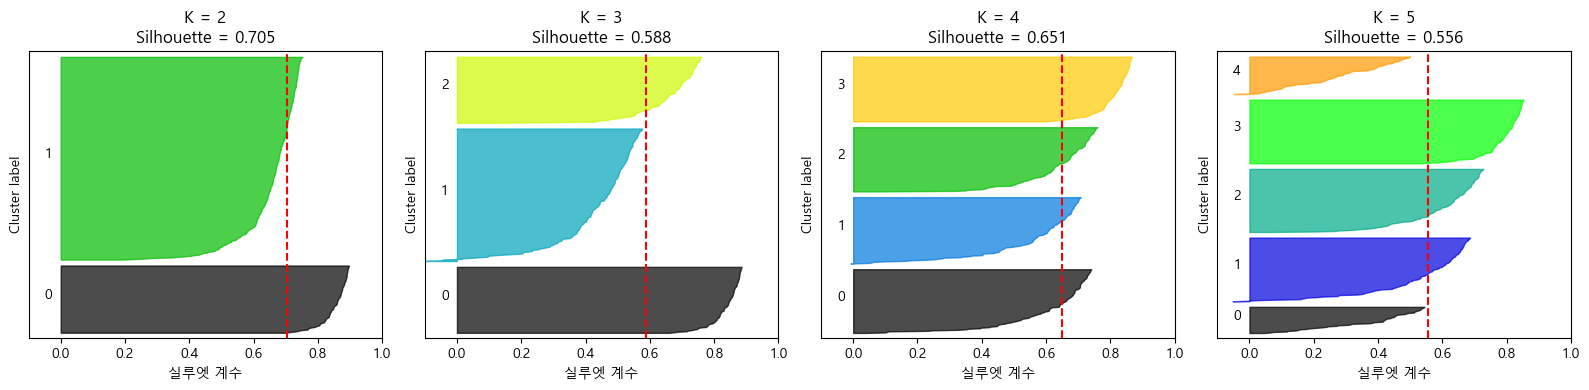

In [6]:
# make_blobs 인공 데이터 (실제 중심 4개) → K=2,3,4,5 비교
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=500, n_features=2, centers=4, cluster_std=1,
                  center_box=(-10.0, 10.0), shuffle=True, random_state=1)

# K=4일 때 평균 실루엣 가장 높고, 클러스터별 면적도 균형 → 최적
visualize_silhouette([2, 3, 4, 5], X)

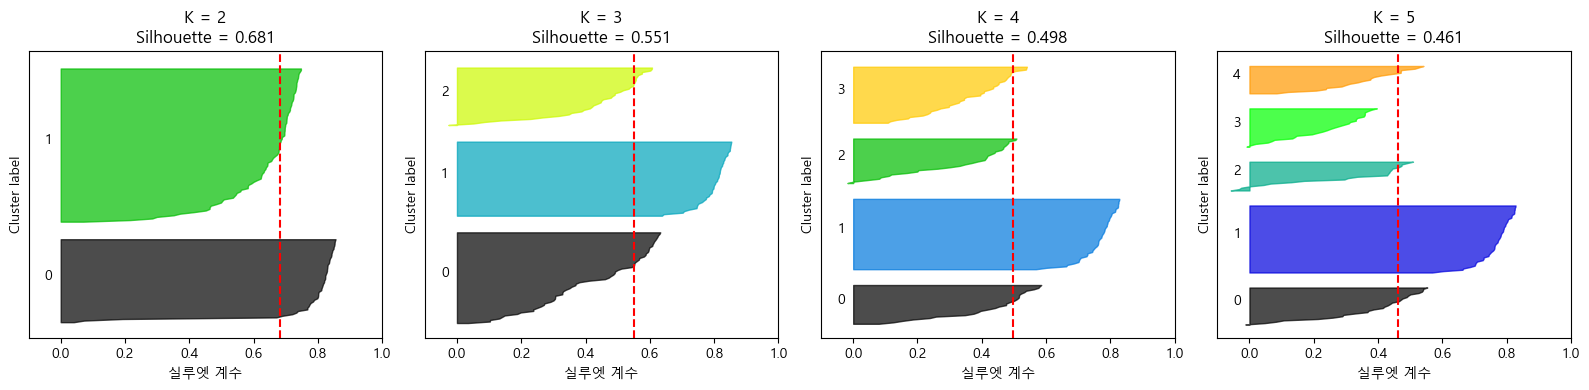

In [7]:
# 붓꽃 데이터에서 최적 K 탐색
from sklearn.datasets import load_iris
iris = load_iris()
visualize_silhouette([2, 3, 4, 5], iris.data)
# K=2가 평균 실루엣은 높지만 클러스터 간 크기 불균형
# K=3가 생물학적으로도 의미 있고 실루엣도 양호

---
## 정리

| 항목 | 내용 |
|------|------|
| K-Means | 중심 반복 업데이트로 군집화, `init='k-means++'`가 기본값 |
| `fit_predict()` | 학습 + 클러스터 번호 할당을 한 번에 |
| `cluster_centers_` | 각 클러스터 중심 좌표 |
| PCA | 고차원 데이터를 2D로 축소해 시각화 |
| 실루엣 계수 | -1~1, 1에 가까울수록 좋은 클러스터링 |
| `silhouette_score()` | 전체 평균 실루엣 계수 |
| `silhouette_samples()` | 샘플별 실루엣 계수 |
| 최적 K 선택 기준 | 평균 실루엣↑ + 클러스터별 면적 균형 |